# K-Nearest Neighbors (KNN)

## Overview

**K-Nearest Neighbors** is a simple, intuitive, and surprisingly powerful non-parametric algorithm. Unlike most machine learning methods, KNN does not build an explicit model during training. Instead, it memorizes the entire training set and defers all computation to prediction time — a strategy known as **lazy learning**.

KNN works on a fundamental principle: *similar inputs tend to have similar outputs*. When predicting a new sample, it finds the K closest training points and aggregates their labels.

---

## How It Works

Given a query point $\mathbf{x}$:

1. **Compute distances** from $\mathbf{x}$ to every training sample.
2. **Find the K nearest neighbors** — the K samples with the smallest distances.
3. **Aggregate** their labels:
   - **Classification:** majority vote among the K neighbors.
   - **Regression:** mean (or weighted mean) of the K neighbor values.

$$\hat{y} = \text{majority}\left\{ y^{(i)} : i \in \mathcal{N}_k(\mathbf{x}) \right\}$$

---

## Distance Metrics

The choice of distance metric determines what "nearest" means. Three metrics are supported:

| Metric | Formula |
|---|---|
| **Euclidean (L2)** | $d(\mathbf{x}, \mathbf{z}) = \sqrt{\sum_j (x_j - z_j)^2}$ |
| **Manhattan (L1)** | $d(\mathbf{x}, \mathbf{z}) = \sum_j \|x_j - z_j\|$ |
| **Minkowski (Lp)** | $d(\mathbf{x}, \mathbf{z}) = \left(\sum_j \|x_j - z_j\|^p\right)^{1/p}$ |

Euclidean is the default and the most common choice. Manhattan is more robust to outliers. Minkowski generalizes both.

---

## Choosing K

The value of K controls the **bias-variance tradeoff**:

- **Small K (e.g. K=1):** Low bias, high variance — decision boundary is jagged and sensitive to noise.
- **Large K:** High bias, low variance — decision boundary is smoother but may underfit.

A common heuristic is to try $K = \sqrt{n}$ where $n$ is the number of training samples, then tune with cross-validation.

---

## Distance Weighting

With uniform weighting, all K neighbors contribute equally. With **distance weighting**, closer neighbors have more influence:

$$\hat{y} = \frac{\sum_{i \in \mathcal{N}_k} w_i y^{(i)}}{\sum_{i \in \mathcal{N}_k} w_i}, \qquad w_i = \frac{1}{d(\mathbf{x}, \mathbf{x}^{(i)})}$$

This can improve performance near class boundaries.

---

## Key Properties

| Property | Detail |
|---|---|
| **Type** | Non-parametric, instance-based |
| **Training** | O(1) — just stores data |
| **Prediction** | O(n · d) per query — computes all distances |
| **Supports** | Classification and regression |
| **Assumption** | Similar inputs have similar outputs |
| **Limitation** | Slow at prediction time for large datasets; sensitive to feature scale |

 EXPERIMENT 1 — Effect of K on Decision Boundary


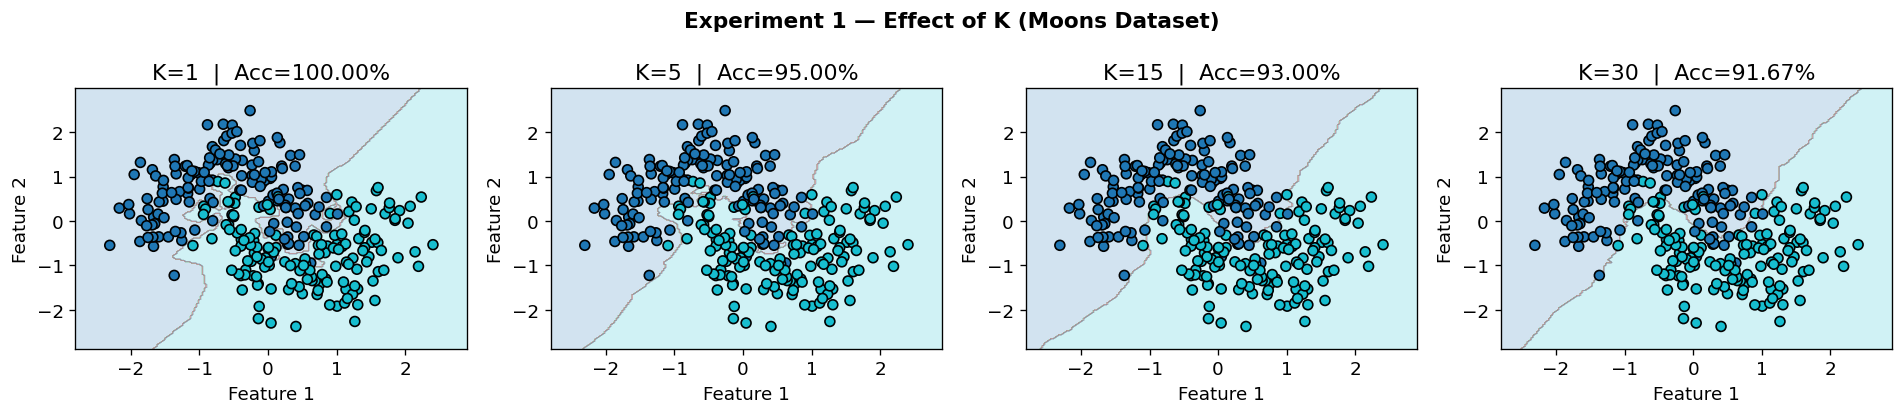

 EXPERIMENT 2 — Optimal K Selection


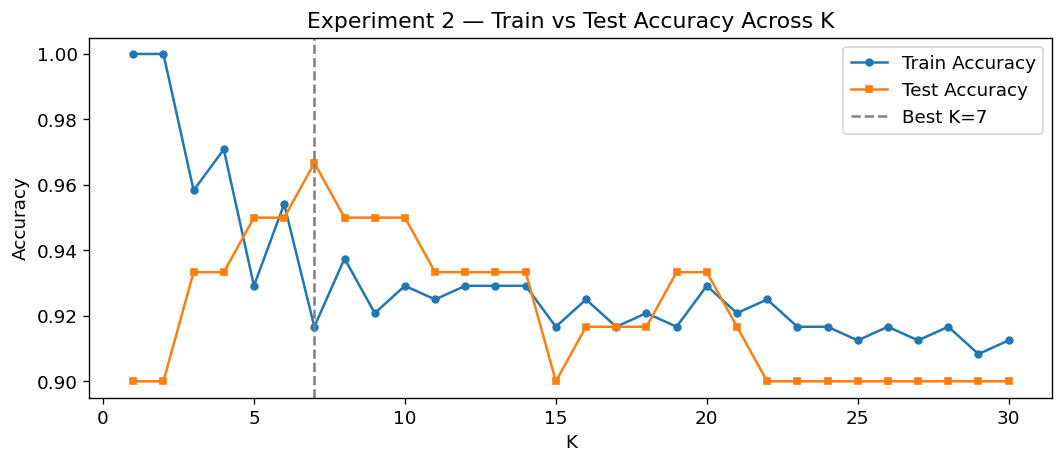

Best K : 7  |  Test Accuracy : 96.67%

 EXPERIMENT 3 — Distance Metric Comparison


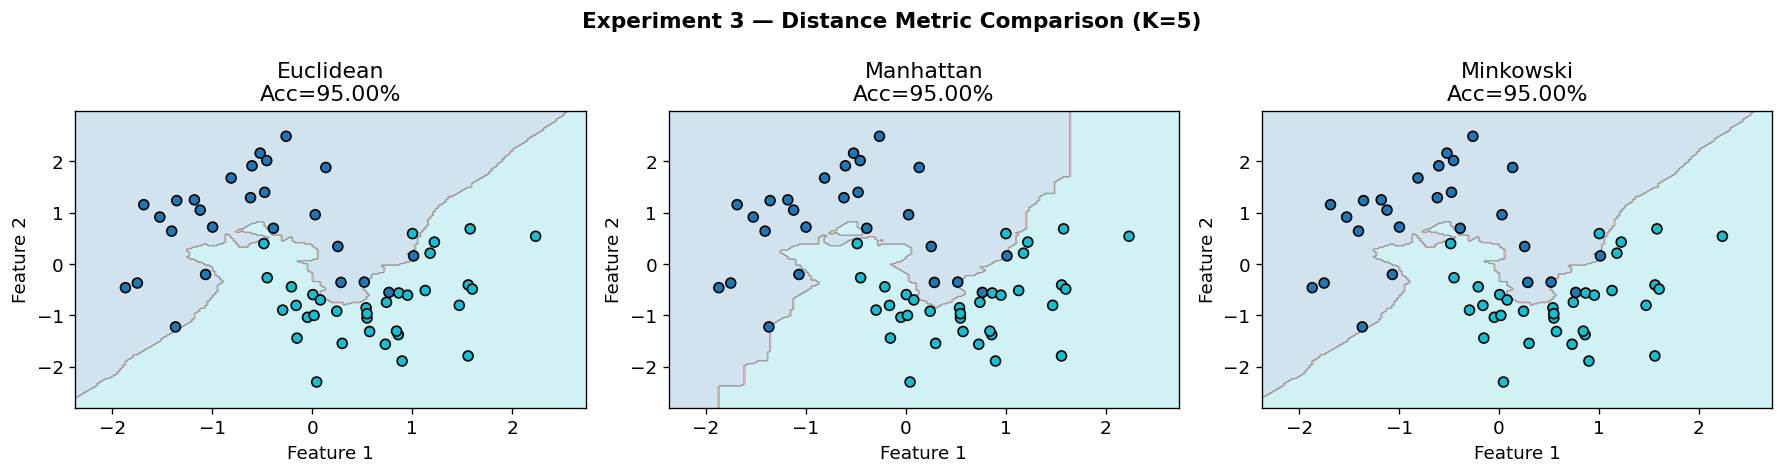

 EXPERIMENT 4 — Iris Dataset (Multiclass)
Test Accuracy : 93.33%

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



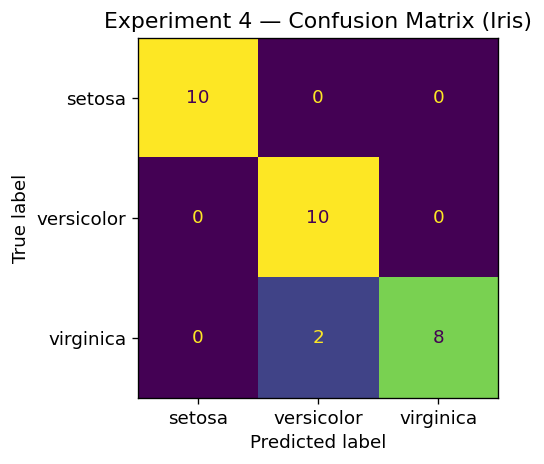

 EXPERIMENT 5 — Uniform vs Distance Weighting


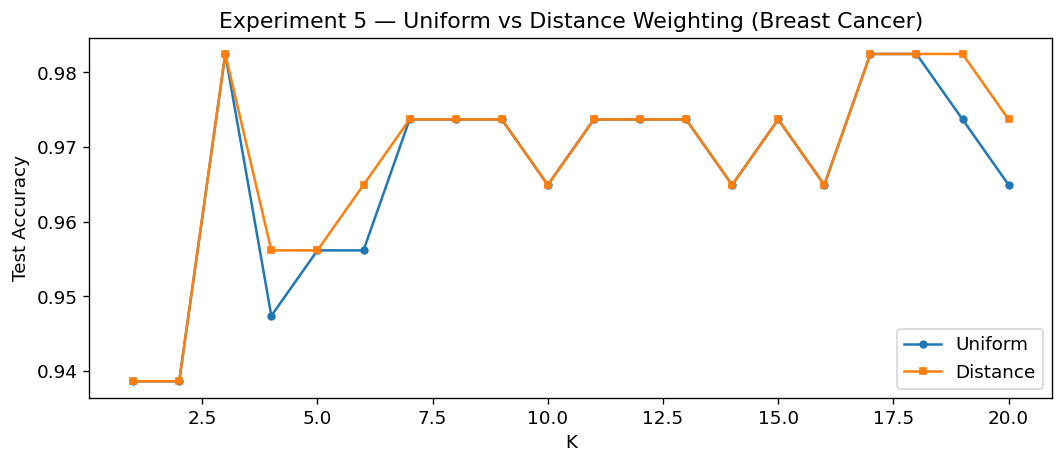

Best Uniform  : K=3, Acc=98.25%
Best Distance : K=3, Acc=98.25%


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_breast_cancer, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import sys, os
sys.path.append(os.path.abspath("../../"))
from mlpackage.supervised_learning.knn import KNN

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})


# ── Helper ────────────────────────────────────────────────────────────────────
def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.2, cmap="tab10")
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap="tab10", edgecolors="k", s=35)
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")


# ── 1. Effect of K on Decision Boundary ──────────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 1 — Effect of K on Decision Boundary")
print("=" * 55)

X_moon, y_moon = make_moons(n_samples=300, noise=0.25, random_state=42)
X_moon = StandardScaler().fit_transform(X_moon)

k_values = [1, 5, 15, 30]
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, k in zip(axes, k_values):
    clf = KNN(k=k)
    clf.fit(X_moon, y_moon)
    plot_decision_boundary(clf, X_moon, y_moon, ax,
        f"K={k}  |  Acc={clf.score(X_moon, y_moon):.2%}")

plt.suptitle("Experiment 1 — Effect of K (Moons Dataset)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


# ── 2. Choosing Optimal K via Cross-Validation ────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 2 — Optimal K Selection")
print("=" * 55)

X_tr, X_te, y_tr, y_te = train_test_split(X_moon, y_moon, test_size=0.2, random_state=42)

k_range = range(1, 31)
train_accs, test_accs = [], []
for k in k_range:
    clf = KNN(k=k)
    clf.fit(X_tr, y_tr)
    train_accs.append(clf.score(X_tr, y_tr))
    test_accs.append(clf.score(X_te, y_te))

best_k = k_range[np.argmax(test_accs)]
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_range, train_accs, marker="o", markersize=4, label="Train Accuracy")
ax.plot(k_range, test_accs,  marker="s", markersize=4, label="Test Accuracy")
ax.axvline(best_k, color="gray", linestyle="--", label=f"Best K={best_k}")
ax.set_xlabel("K")
ax.set_ylabel("Accuracy")
ax.set_title("Experiment 2 — Train vs Test Accuracy Across K")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Best K : {best_k}  |  Test Accuracy : {max(test_accs):.2%}\n")


# ── 3. Distance Metrics Comparison ───────────────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 3 — Distance Metric Comparison")
print("=" * 55)

metrics = ["euclidean", "manhattan", "minkowski"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, metrics):
    clf = KNN(k=5, metric=metric)
    clf.fit(X_tr, y_tr)
    plot_decision_boundary(clf, X_te, y_te, ax,
        f"{metric.capitalize()}\nAcc={clf.score(X_te, y_te):.2%}")

plt.suptitle("Experiment 3 — Distance Metric Comparison (K=5)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


# ── 4. Real Dataset — Iris (Multiclass) ──────────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 4 — Iris Dataset (Multiclass)")
print("=" * 55)

iris = load_iris()
X_iris, y_iris = iris.data, iris.target
X_tr_i, X_te_i, y_tr_i, y_te_i = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris)

sc = StandardScaler()
X_tr_is = sc.fit_transform(X_tr_i)
X_te_is  = sc.transform(X_te_i)

clf_iris = KNN(k=5)
clf_iris.fit(X_tr_is, y_tr_i)
y_pred_iris = clf_iris.predict(X_te_is)

print(f"Test Accuracy : {clf_iris.score(X_te_is, y_te_i):.2%}\n")
print(classification_report(y_te_i, y_pred_iris, target_names=iris.target_names))

fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay(confusion_matrix(y_te_i, y_pred_iris),
                       display_labels=iris.target_names).plot(ax=ax, colorbar=False)
ax.set_title("Experiment 4 — Confusion Matrix (Iris)")
plt.tight_layout()
plt.show()


# ── 5. Uniform vs Distance Weighting ─────────────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 5 — Uniform vs Distance Weighting")
print("=" * 55)

data = load_breast_cancer()
X_b, y_b = data.data, data.target
X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X_b, y_b, test_size=0.2, random_state=42, stratify=y_b)
sc = StandardScaler()
X_tr_bs = sc.fit_transform(X_tr_b)
X_te_bs  = sc.transform(X_te_b)

k_range2 = range(1, 21)
uniform_accs, distance_accs = [], []
for k in k_range2:
    for accs, w in [(uniform_accs, "uniform"), (distance_accs, "distance")]:
        clf = KNN(k=k, weights=w)
        clf.fit(X_tr_bs, y_tr_b)
        accs.append(clf.score(X_te_bs, y_te_b))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_range2, uniform_accs,  marker="o", markersize=4, label="Uniform")
ax.plot(k_range2, distance_accs, marker="s", markersize=4, label="Distance")
ax.set_xlabel("K")
ax.set_ylabel("Test Accuracy")
ax.set_title("Experiment 5 — Uniform vs Distance Weighting (Breast Cancer)")
ax.legend()
plt.tight_layout()
plt.show()

best_k_u = list(k_range2)[np.argmax(uniform_accs)]
best_k_d = list(k_range2)[np.argmax(distance_accs)]
print(f"Best Uniform  : K={best_k_u}, Acc={max(uniform_accs):.2%}")
print(f"Best Distance : K={best_k_d}, Acc={max(distance_accs):.2%}")